In [ ]:
import zipfile
import os

zip_path = "/content/UCI HAR Dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir('/content'))
data_path = "/content/UCI HAR Dataset"

print("Dataset contents:")
print(os.listdir(data_path))

['.config', 'UCI HAR Dataset', '__MACOSX', 'UCI HAR Dataset.zip', 'sample_data']
Dataset contents:
['test', 'activity_labels.txt', '.DS_Store', 'features.txt', 'features_info.txt', 'train', 'README.txt']


In [ ]:
train_signal_path = os.path.join(
    data_path,
    "train",
    "Inertial Signals"
)

print("Training raw signal files:")
print(os.listdir(train_signal_path))

Training raw signal files:
['body_gyro_y_train.txt', 'body_gyro_z_train.txt', 'body_acc_x_train.txt', 'body_acc_z_train.txt', 'body_gyro_x_train.txt', 'body_acc_y_train.txt', 'total_acc_y_train.txt', 'total_acc_z_train.txt', 'total_acc_x_train.txt']


In [ ]:
import numpy as np
import os

data_path = "/content/UCI HAR Dataset"

train_signal_path = os.path.join(
    data_path,
    "train",
    "Inertial Signals"
)

test_signal_path = os.path.join(
    data_path,
    "test",
    "Inertial Signals"
)

signal_names = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

# Load training signals
train_signals = []

for signal in signal_names:
    file_path = os.path.join(
        train_signal_path,
        signal + "_train.txt"
    )

    data = np.loadtxt(file_path)
    train_signals.append(data)

# Load testing signals
test_signals = []

for signal in signal_names:
    file_path = os.path.join(
        test_signal_path,
        signal + "_test.txt"
    )

    data = np.loadtxt(file_path)
    test_signals.append(data)

print("Number of training signals:", len(train_signals))
print("Number of testing signals:", len(test_signals))

print("Shape of one training signal:", train_signals[0].shape)
print("Shape of one testing signal:", test_signals[0].shape)

Number of training signals: 9
Number of testing signals: 9
Shape of one training signal: (7352, 128)
Shape of one testing signal: (2947, 128)


In [ ]:
X_train_full = np.stack(train_signals, axis=-1)
X_test_full = np.stack(test_signals, axis=-1)

print("Full training tensor shape:", X_train_full.shape)
print("Full testing tensor shape:", X_test_full.shape)

Full training tensor shape: (7352, 128, 9)
Full testing tensor shape: (2947, 128, 9)


In [ ]:
y_train_full = np.loadtxt(
    os.path.join(data_path, "train", "y_train.txt")
).astype(int)

y_test_full = np.loadtxt(
    os.path.join(data_path, "test", "y_test.txt")
).astype(int)

print("Training labels shape:", y_train_full.shape)
print("Testing labels shape:", y_test_full.shape)

print("First 10 training labels:")
print(y_train_full[:10])

Training labels shape: (7352,)
Testing labels shape: (2947,)
First 10 training labels:
[5 5 5 5 5 5 5 5 5 5]


In [ ]:
activity_labels = {}

with open(
    os.path.join(data_path, "activity_labels.txt"),
    "r"
) as file:
    for line in file:
        number, name = line.strip().split()
        activity_labels[int(number)] = name

print("Activity labels:")
for number, name in activity_labels.items():
    print(number, "→", name)

Activity labels:
1 → WALKING
2 → WALKING_UPSTAIRS
3 → WALKING_DOWNSTAIRS
4 → SITTING
5 → STANDING
6 → LAYING


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
for activity_id, activity_name in activity_labels.items():
    count = np.sum(y_train_full == activity_id)
    print(f"{activity_id} - {activity_name}: {count} samples")

1 - WALKING: 1226 samples
2 - WALKING_UPSTAIRS: 1073 samples
3 - WALKING_DOWNSTAIRS: 986 samples
4 - SITTING: 1286 samples
5 - STANDING: 1374 samples
6 - LAYING: 1407 samples


In [ ]:
selected_activities = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    4: "SITTING"
}

In [ ]:
representative_samples = {}

for activity_id, activity_name in selected_activities.items():
    index = np.where(y_train_full == activity_id)[0][0]
    representative_samples[activity_id] = index

    print(
        activity_name,
        "→ sample index:",
        index
    )

WALKING → sample index: 78
WALKING_UPSTAIRS → sample index: 150
SITTING → sample index: 27


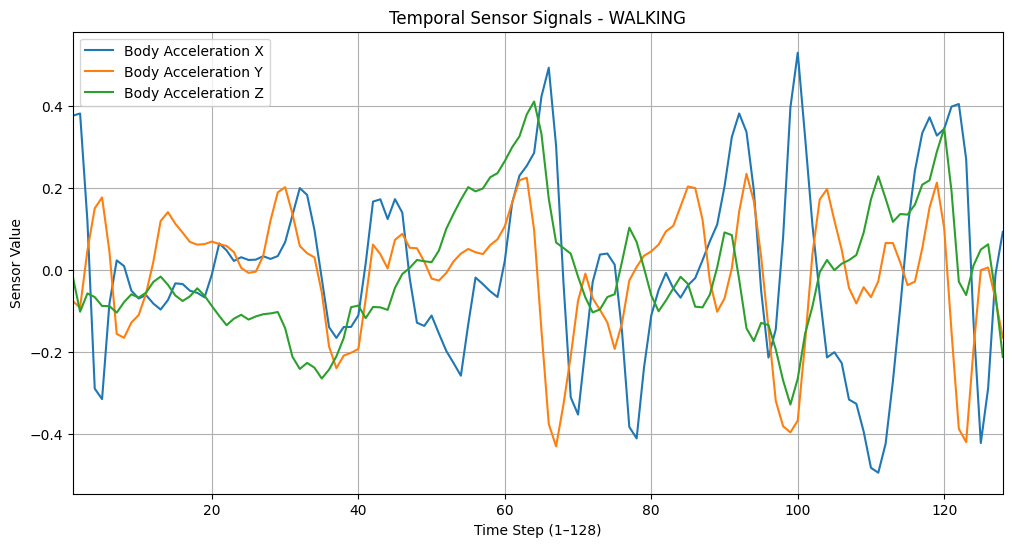

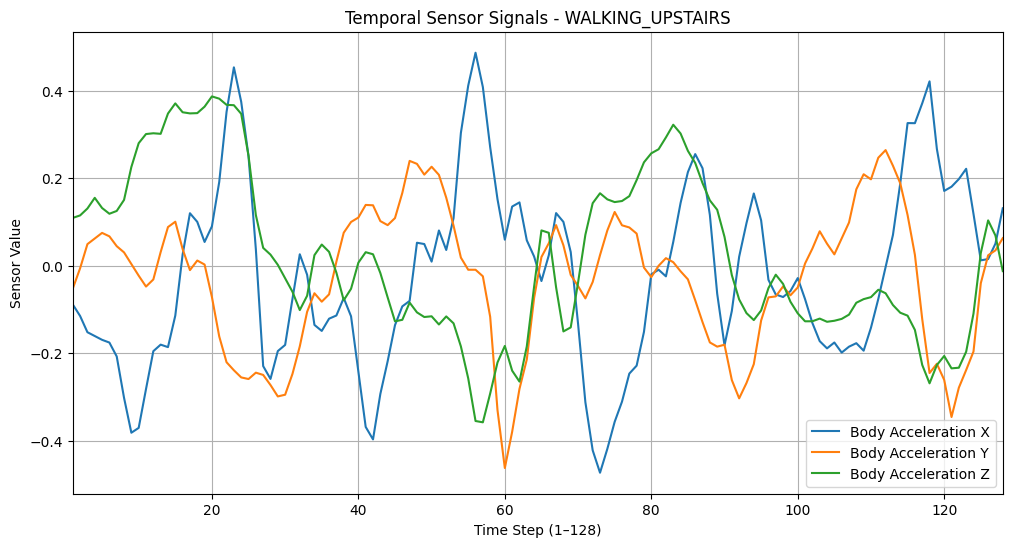

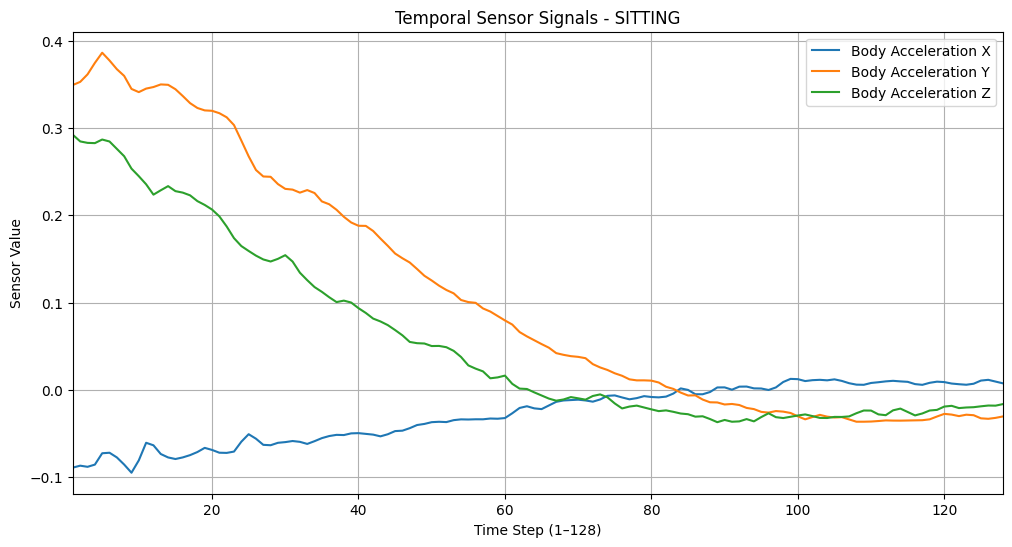

In [ ]:
sensor_names = [
    "Body Acceleration X",
    "Body Acceleration Y",
    "Body Acceleration Z"
]

sensor_indices = [0, 1, 2]

time_steps = np.arange(1, 129)

for activity_id, activity_name in selected_activities.items():

    index = representative_samples[activity_id]

    sequence = X_train_full[index]

    plt.figure(figsize=(12, 6))

    for sensor_index, sensor_name in zip(
        sensor_indices,
        sensor_names
    ):
        plt.plot(
            time_steps,
            sequence[:, sensor_index],
            label=sensor_name
        )

    plt.title(
        f"Temporal Sensor Signals - {activity_name}"
    )

    plt.xlabel("Time Step (1–128)")
    plt.ylabel("Sensor Value")

    plt.xlim(1, 128)
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [ ]:
rnn_model = Sequential([
    SimpleRNN(
        64,
        activation="tanh",
        input_shape=(128, 9)
    ),

    Dense(
        6,
        activation="softmax"
    )
])

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,126 (20.02 KB)

 Trainable params: 5,126 (20.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print("X_train_full:", X_train_full.shape)
print("X_test_full:", X_test_full.shape)
print("y_train_full:", y_train_full.shape)
print("y_test_full:", y_test_full.shape)

X_train_full: (7352, 128, 9)
X_test_full: (2947, 128, 9)
y_train_full: (7352,)
y_test_full: (2947,)


In [ ]:
import numpy as np

samples_per_class = 500

selected_indices = []

for class_id in range(1, 7):
    class_indices = np.where(y_train_full == class_id)[0]

    # Take first 500 samples from this class
    selected_indices.extend(
        class_indices[:samples_per_class]
    )

selected_indices = np.array(selected_indices)

print("Total selected samples:", len(selected_indices))

Total selected samples: 3000


In [ ]:
X_subset = X_train_full[selected_indices]
y_subset = y_train_full[selected_indices]

print("X_subset shape:", X_subset.shape)
print("y_subset shape:", y_subset.shape)

X_subset shape: (3000, 128, 9)
y_subset shape: (3000,)


In [ ]:
y_subset = y_subset - 1

In [ ]:
print("Unique labels:", np.unique(y_subset))

Unique labels: [0 1 2 3 4 5]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_subset,
    y_subset,
    test_size=0.30,
    random_state=42,
    stratify=y_subset
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Training :", X_train.shape)
print("Validation:", X_val.shape)
print("Testing  :", X_test.shape)

print("Training labels :", y_train.shape)
print("Validation labels:", y_val.shape)
print("Testing labels  :", y_test.shape)

Training : (2100, 128, 9)
Validation: (450, 128, 9)
Testing  : (450, 128, 9)
Training labels : (2100,)
Validation labels: (450,)
Testing labels  : (450,)


In [ ]:
train_mean = np.mean(X_train, axis=(0, 1), keepdims=True)
train_std = np.std(X_train, axis=(0, 1), keepdims=True)

# Avoid division by zero
train_std[train_std == 0] = 1

In [ ]:
X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

In [ ]:
print("Training mean:", np.mean(X_train))
print("Training std :", np.std(X_train))

Training mean: 3.691932121570957e-17
Training std : 1.0000000000000038


In [ ]:
from collections import Counter

print("Training distribution:")
print(Counter(y_train))

print("\nValidation distribution:")
print(Counter(y_val))

print("\nTesting distribution:")
print(Counter(y_test))

Training distribution:
Counter({np.int64(2): 350, np.int64(4): 350, np.int64(5): 350, np.int64(3): 350, np.int64(1): 350, np.int64(0): 350})

Validation distribution:
Counter({np.int64(2): 75, np.int64(1): 75, np.int64(4): 75, np.int64(5): 75, np.int64(3): 75, np.int64(0): 75})

Testing distribution:
Counter({np.int64(3): 75, np.int64(4): 75, np.int64(1): 75, np.int64(5): 75, np.int64(2): 75, np.int64(0): 75})


In [ ]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5314 - loss: 1.1452 - val_accuracy: 0.6333 - val_loss: 0.8516
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6510 - loss: 0.8638 - val_accuracy: 0.6600 - val_loss: 0.7718
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7238 - loss: 0.6503 - val_accuracy: 0.7244 - val_loss: 0.6432
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7690 - loss: 0.5900 - val_accuracy: 0.7689 - val_loss: 0.5940
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7829 - loss: 0.6062 - val_accuracy: 0.7267 - val_loss: 0.6677
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8214 - loss: 0.5292 - val_accuracy: 0.7822 - val_loss: 0.5372
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8057 - loss: 0.5531 - val_accuracy: 0.7978 - val_loss: 0.5186
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8557 - loss: 0.4226 - val_accuracy: 0.8400 - v

In [ ]:
test_loss, test_accuracy = rnn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("RNN Test Loss:", test_loss)
print("RNN Test Accuracy:", test_accuracy)

RNN Test Loss: 0.19435127079486847
RNN Test Accuracy: 0.9399999976158142


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential([
    SimpleRNN(
        32,
        activation="tanh",
        input_shape=(128, 9)
    ),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        6,
        activation="softmax"
    )
])

rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = Adam(learning_rate=0.001)

In [ ]:
rnn_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4067 - loss: 1.5340 - val_accuracy: 0.5267 - val_loss: 1.2753
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5724 - loss: 1.1507 - val_accuracy: 0.6022 - val_loss: 1.0091
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6186 - loss: 0.9626 - val_accuracy: 0.6267 - val_loss: 0.8922
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6614 - loss: 0.8080 - val_accuracy: 0.6667 - val_loss: 0.7468
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6414 - loss: 0.8166 - val_accuracy: 0.6644 - val_loss: 0.7489
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6290 - loss: 0.9075 - val_accuracy: 0.5533 - val_loss: 1.0882
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5700 - loss: 0.9536 - val_accuracy: 0.5867 - val_loss: 0.8205
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6105 - loss: 0.8528 - val_accuracy: 0.6422 - v

In [ ]:
from tensorflow.keras.layers import LSTM, GRU

In [ ]:
lstm_model = Sequential([
    LSTM(
        32,
        activation="tanh",
        input_shape=(128, 9)
    ),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        6,
        activation="softmax"
    )
])

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.4200 - loss: 1.5117 - val_accuracy: 0.5244 - val_loss: 1.1849
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6267 - loss: 0.9306 - val_accuracy: 0.7489 - val_loss: 0.7207
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.7748 - loss: 0.5636 - val_accuracy: 0.8556 - val_loss: 0.4398
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7995 - loss: 0.5208 - val_accuracy: 0.8511 - val_loss: 0.4054
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8519 - loss: 0.4124 - val_accuracy: 0.8800 - val_loss: 0.3444
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.8748 - loss: 0.3533 - val_accuracy: 0.9089 - val_loss: 0.2815
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9048 - loss: 0.2846 - val_accuracy: 0.9178 - val_loss: 0.2304
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9143 - loss: 0.2495 - val_accuracy: 0.9289 - v

In [ ]:
gru_model = Sequential([
    GRU(
        32,
        activation="tanh",
        input_shape=(128, 9)
    ),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        6,
        activation="softmax"
    )
])

gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.3024 - loss: 1.5786 - val_accuracy: 0.5111 - val_loss: 1.3583
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.5043 - loss: 1.2314 - val_accuracy: 0.5889 - val_loss: 1.0455
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.6290 - loss: 0.8438 - val_accuracy: 0.7133 - val_loss: 0.6881
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.7352 - loss: 0.6221 - val_accuracy: 0.7822 - val_loss: 0.5351
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8252 - loss: 0.4673 - val_accuracy: 0.8800 - val_loss: 0.3974
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.8590 - loss: 0.3627 - val_accuracy: 0.8822 - val_loss: 0.3343
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9167 - loss: 0.2738 - val_accuracy: 0.9289 - val_loss: 0.2179
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9448 - loss: 0.1987 - val_accuracy: 0.9467 - v

In [ ]:
import numpy as np

# RNN predictions
rnn_prob = rnn_model.predict(X_test)
rnn_pred = np.argmax(rnn_prob, axis=1)

# LSTM predictions
lstm_prob = lstm_model.predict(X_test)
lstm_pred = np.argmax(lstm_prob, axis=1)

# GRU predictions
gru_prob = gru_model.predict(X_test)
gru_pred = np.argmax(gru_prob, axis=1)

print("Predictions generated successfully!")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Predictions generated successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def calculate_metrics(y_true, y_pred, model_name):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    print(f"\n{model_name}")
    print("-" * 30)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    return accuracy, precision, recall, f1

In [ ]:
rnn_metrics = calculate_metrics(
    y_test,
    rnn_pred,
    "Vanilla RNN"
)

lstm_metrics = calculate_metrics(
    y_test,
    lstm_pred,
    "LSTM"
)

gru_metrics = calculate_metrics(
    y_test,
    gru_pred,
    "GRU"
)


Vanilla RNN
------------------------------
Accuracy : 0.7467
Precision: 0.7485
Recall   : 0.7467
F1-score : 0.7433

LSTM
------------------------------
Accuracy : 0.9267
Precision: 0.9270
Recall   : 0.9267
F1-score : 0.9266

GRU
------------------------------
Accuracy : 0.9511
Precision: 0.9525
Recall   : 0.9511
F1-score : 0.9510


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Vanilla RNN",
        "LSTM",
        "GRU"
    ],

    "Accuracy": [
        rnn_metrics[0],
        lstm_metrics[0],
        gru_metrics[0]
    ],

    "Precision": [
        rnn_metrics[1],
        lstm_metrics[1],
        gru_metrics[1]
    ],

    "Recall": [
        rnn_metrics[2],
        lstm_metrics[2],
        gru_metrics[2]
    ],

    "F1-Score": [
        rnn_metrics[3],
        lstm_metrics[3],
        gru_metrics[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Vanilla RNN,0.746667,0.748471,0.746667,0.743318
1,LSTM,0.926667,0.926978,0.926667,0.926648
2,GRU,0.951111,0.952467,0.951111,0.950972


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
activity_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

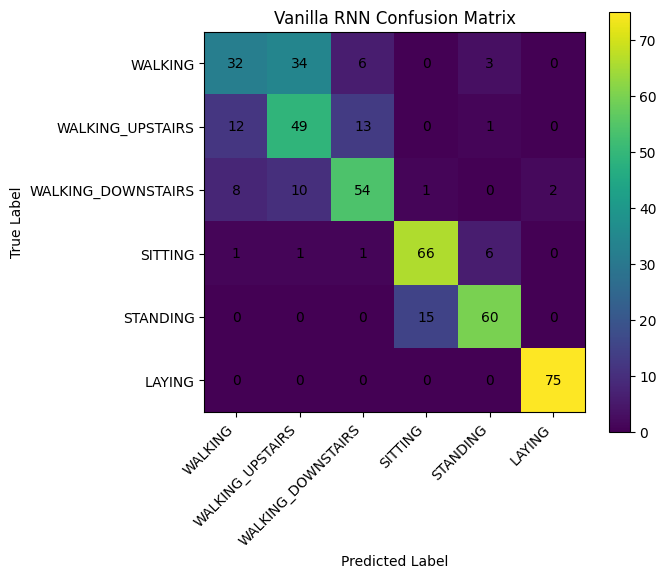

In [ ]:
cm_rnn = confusion_matrix(y_test, rnn_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm_rnn)
plt.title("Vanilla RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(6), activity_names, rotation=45, ha="right")
plt.yticks(range(6), activity_names)

for i in range(6):
    for j in range(6):
        plt.text(j, i, cm_rnn[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

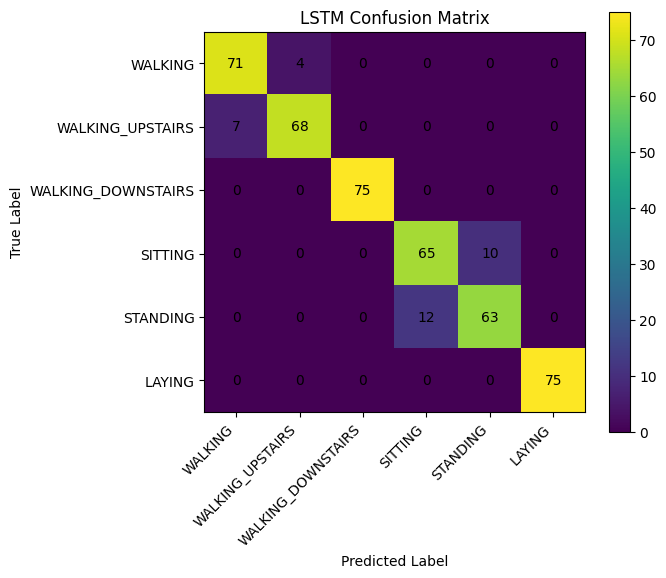

In [ ]:
cm_lstm = confusion_matrix(y_test, lstm_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm_lstm)
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(6), activity_names, rotation=45, ha="right")
plt.yticks(range(6), activity_names)

for i in range(6):
    for j in range(6):
        plt.text(j, i, cm_lstm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

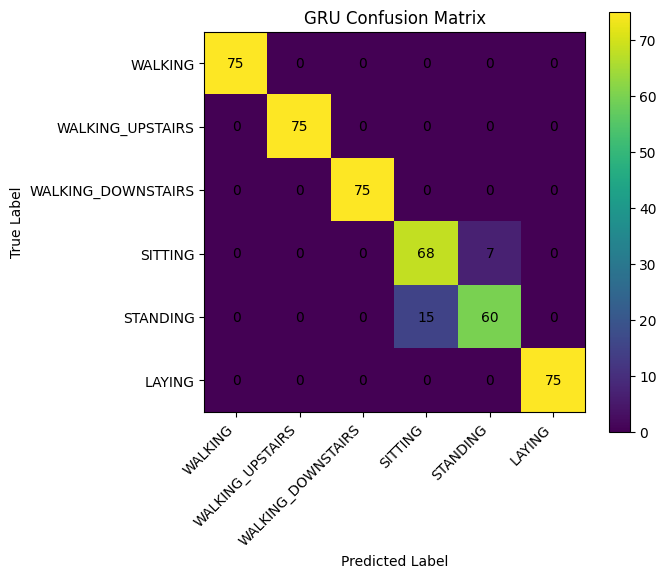

In [ ]:
cm_gru = confusion_matrix(y_test, gru_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm_gru)
plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(6), activity_names, rotation=45, ha="right")
plt.yticks(range(6), activity_names)

for i in range(6):
    for j in range(6):
        plt.text(j, i, cm_gru[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

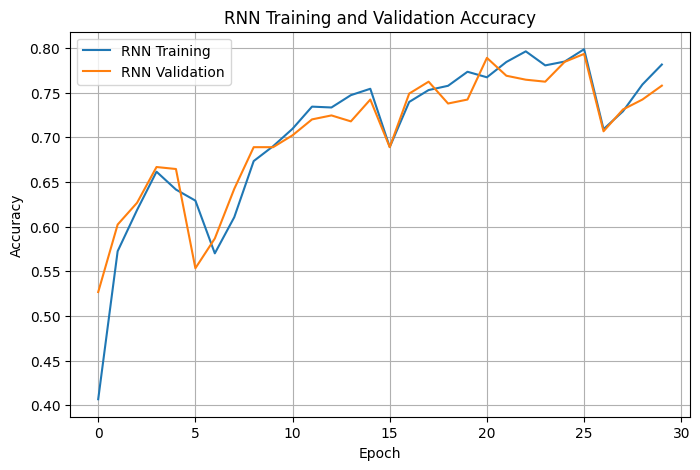

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_rnn.history["accuracy"],
    label="RNN Training"
)

plt.plot(
    history_rnn.history["val_accuracy"],
    label="RNN Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

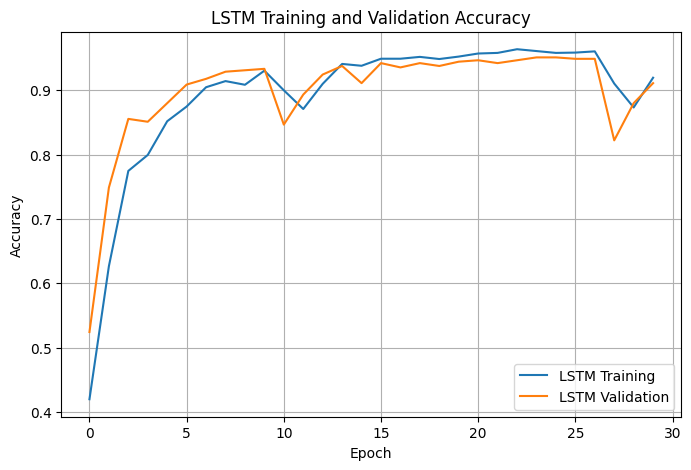

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_lstm.history["accuracy"],
    label="LSTM Training"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    label="LSTM Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

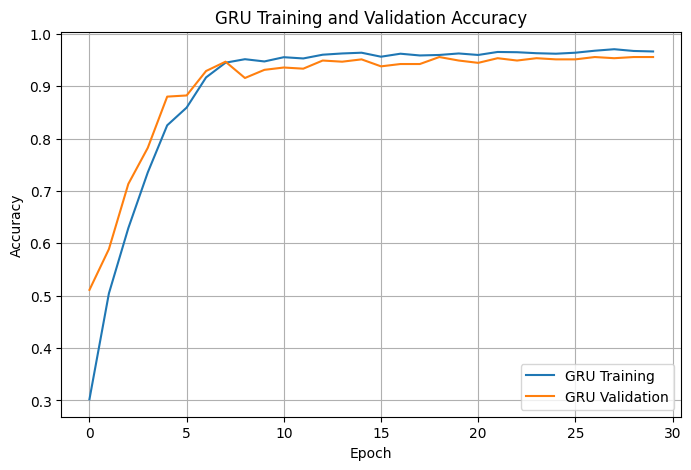

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_gru.history["accuracy"],
    label="GRU Training"
)

plt.plot(
    history_gru.history["val_accuracy"],
    label="GRU Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

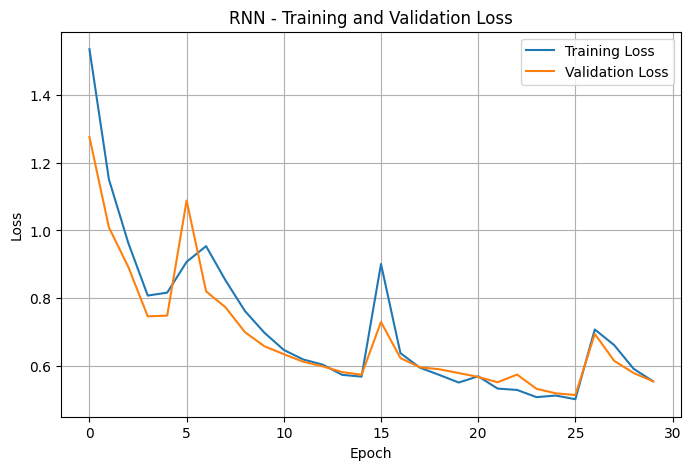

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_rnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_rnn.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

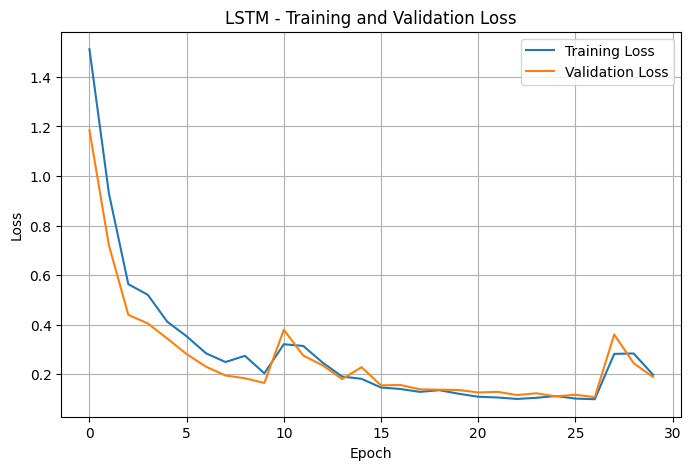

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

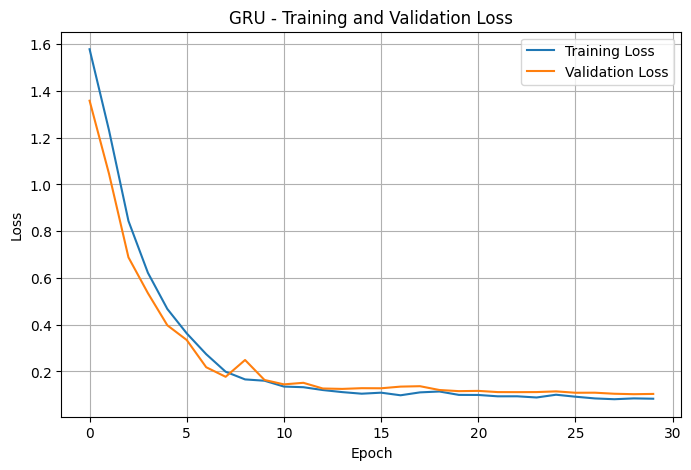

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_gru.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_gru.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

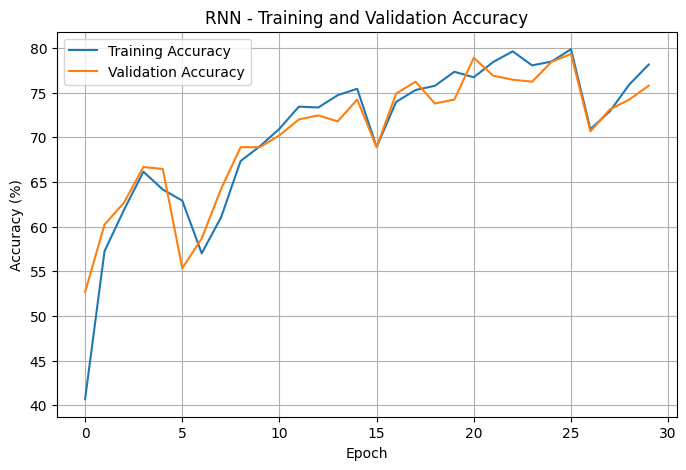

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.array(history_rnn.history["accuracy"]) * 100,
    label="Training Accuracy"
)

plt.plot(
    np.array(history_rnn.history["val_accuracy"]) * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("RNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

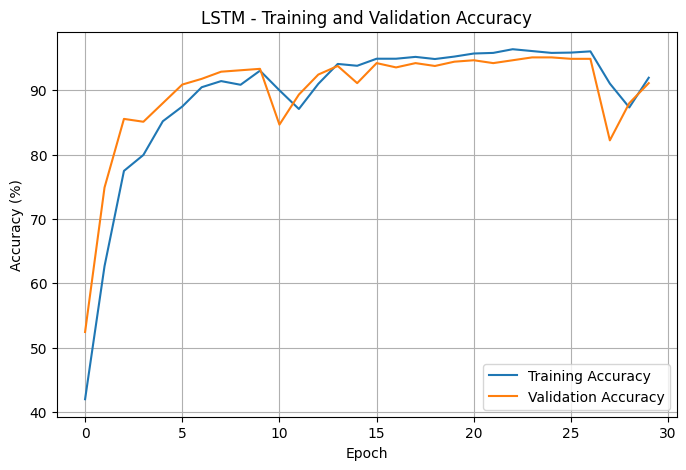

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.array(history_lstm.history["accuracy"]) * 100,
    label="Training Accuracy"
)

plt.plot(
    np.array(history_lstm.history["val_accuracy"]) * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("LSTM - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

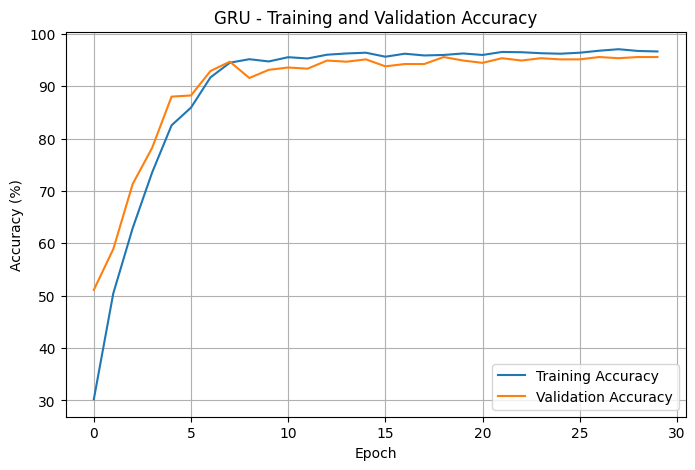

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.array(history_gru.history["accuracy"]) * 100,
    label="Training Accuracy"
)

plt.plot(
    np.array(history_gru.history["val_accuracy"]) * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("GRU - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
rnn_prob = rnn_model.predict(X_test, verbose=0)
lstm_prob = lstm_model.predict(X_test, verbose=0)
gru_prob = gru_model.predict(X_test, verbose=0)

rnn_pred = np.argmax(rnn_prob, axis=1)
lstm_pred = np.argmax(lstm_prob, axis=1)
gru_pred = np.argmax(gru_prob, axis=1)

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(y_true, y_pred, model_name):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="macro"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    print(f"\n{model_name}")
    print("=" * 40)
    print(f"Accuracy        : {accuracy * 100:.2f}%")
    print(f"Macro Precision : {precision * 100:.2f}%")
    print(f"Macro Recall    : {recall * 100:.2f}%")
    print(f"Macro F1        : {f1 * 100:.2f}%")

    return accuracy, precision, recall, f1

In [ ]:
rnn_metrics = evaluate_model(
    y_test,
    rnn_pred,
    "Vanilla RNN"
)

lstm_metrics = evaluate_model(
    y_test,
    lstm_pred,
    "LSTM"
)

gru_metrics = evaluate_model(
    y_test,
    gru_pred,
    "GRU"
)


Vanilla RNN
Accuracy        : 74.67%
Macro Precision : 74.85%
Macro Recall    : 74.67%
Macro F1        : 74.33%

LSTM
Accuracy        : 92.67%
Macro Precision : 92.70%
Macro Recall    : 92.67%
Macro F1        : 92.66%

GRU
Accuracy        : 95.11%
Macro Precision : 95.25%
Macro Recall    : 95.11%
Macro F1        : 95.10%


In [ ]:
print("RNN trainable parameters:",
      rnn_model.count_params())

print("LSTM trainable parameters:",
      lstm_model.count_params())

print("GRU trainable parameters:",
      gru_model.count_params())

RNN trainable parameters: 1974
LSTM trainable parameters: 6006
GRU trainable parameters: 4758


In [ ]:
import time

start_time = time.time()

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

rnn_training_time = time.time() - start_time

print(f"RNN Training Time: {rnn_training_time:.2f} seconds")

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7748 - loss: 0.5423 - val_accuracy: 0.7467 - val_loss: 0.5413
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7643 - loss: 0.5777 - val_accuracy: 0.7422 - val_loss: 0.6034
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7690 - loss: 0.5740 - val_accuracy: 0.7844 - val_loss: 0.5487
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7400 - loss: 0.6207 - val_accuracy: 0.7578 - val_loss: 0.5901
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7648 - loss: 0.5858 - val_accuracy: 0.7711 - val_loss: 0.5663
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7771 - loss: 0.5611 - val_accuracy: 0.7711 - val_loss: 0.5442
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7729 - loss: 0.5363 - val_accuracy: 0.7489 - val_loss: 0.5397
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7781 - loss: 0.5288 - val_accuracy: 0.7711 - v

In [ ]:
start_time = time.time()

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

lstm_training_time = time.time() - start_time

print(f"LSTM Training Time: {lstm_training_time:.2f} seconds")

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9419 - loss: 0.1494 - val_accuracy: 0.9467 - val_loss: 0.1326
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9581 - loss: 0.1125 - val_accuracy: 0.9422 - val_loss: 0.1300
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9638 - loss: 0.0989 - val_accuracy: 0.9489 - val_loss: 0.1200
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9586 - loss: 0.0965 - val_accuracy: 0.9533 - val_loss: 0.1092
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9629 - loss: 0.0889 - val_accuracy: 0.9533 - val_loss: 0.1171
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.9629 - loss: 0.0880 - val_accuracy: 0.9511 - val_loss: 0.1077
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9614 - loss: 0.0914 - val_accuracy: 0.9489 - val_loss: 0.1020
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9667 - loss: 0.0797 - val_accuracy: 0.9511 - v

In [ ]:
start_time = time.time()

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

gru_training_time = time.time() - start_time

print(f"GRU Training Time: {gru_training_time:.2f} seconds")

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9600 - loss: 0.0841 - val_accuracy: 0.9578 - val_loss: 0.0997
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.9662 - loss: 0.0797 - val_accuracy: 0.9556 - val_loss: 0.0996
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9686 - loss: 0.0802 - val_accuracy: 0.9556 - val_loss: 0.0999
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9667 - loss: 0.0804 - val_accuracy: 0.9489 - val_loss: 0.1053
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9624 - loss: 0.0914 - val_accuracy: 0.9333 - val_loss: 0.1631
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9652 - loss: 0.0916 - val_accuracy: 0.9533 - val_loss: 0.0996
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9714 - loss: 0.0766 - val_accuracy: 0.9578 - val_loss: 0.0970
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9686 - loss: 0.0776 - val_accuracy: 0.9578 - v

In [ ]:
from sklearn.metrics import confusion_matrix

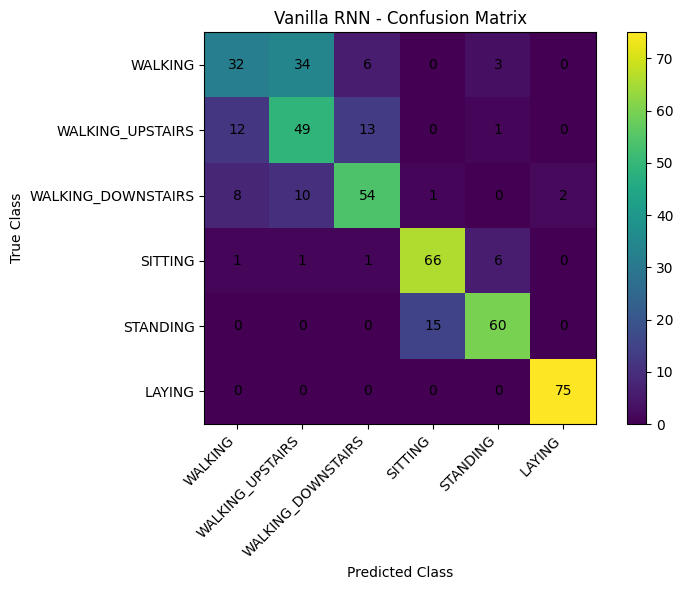

In [ ]:
cm_rnn = confusion_matrix(y_test, rnn_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm_rnn)

plt.title("Vanilla RNN - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(6),
    activity_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(6),
    activity_names
)

for i in range(6):
    for j in range(6):
        plt.text(
            j,
            i,
            cm_rnn[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


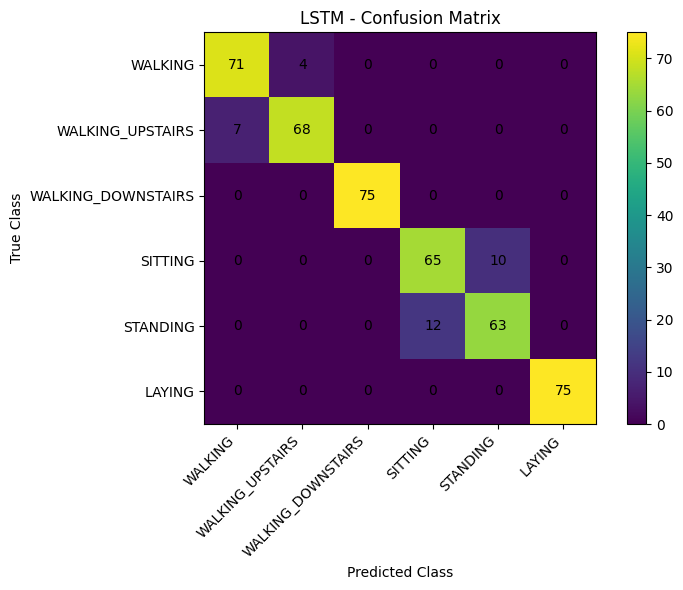

In [ ]:
cm_lstm = confusion_matrix(y_test, lstm_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm_lstm)

plt.title("LSTM - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(6),
    activity_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(6),
    activity_names
)

for i in range(6):
    for j in range(6):
        plt.text(
            j,
            i,
            cm_lstm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

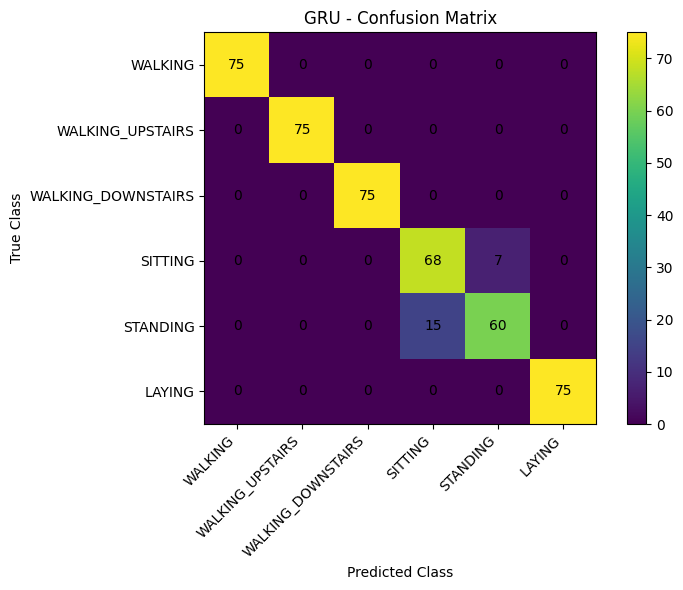

In [ ]:
cm_gru = confusion_matrix(y_test, gru_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm_gru)

plt.title("GRU - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(6),
    activity_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(6),
    activity_names
)

for i in range(6):
    for j in range(6):
        plt.text(
            j,
            i,
            cm_gru[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
def analyze_confusion_matrix(cm, activity_names, model_name):

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    # Recognition rate for each class
    recognition_rates = np.diag(cm) / np.sum(
        cm,
        axis=1
    )

    print("\nRecognition rate by activity:")

    for name, rate in zip(
        activity_names,
        recognition_rates
    ):
        print(f"{name}: {rate * 100:.2f}%")

    # Highest recognition
    best_index = np.argmax(recognition_rates)

    print(
        f"\nHighest recognition rate: "
        f"{activity_names[best_index]} "
        f"({recognition_rates[best_index] * 100:.2f}%)"
    )

    # Misclassifications per class
    misclassifications = np.sum(cm, axis=1) - np.diag(cm)

    worst_index = np.argmax(misclassifications)

    print(
        f"Largest number of misclassifications: "
        f"{activity_names[worst_index]} "
        f"({misclassifications[worst_index]})"
    )

    # Find confusion pairs
    confusion_pairs = []

    for i in range(len(activity_names)):
        for j in range(len(activity_names)):

            if i != j and cm[i, j] > 0:

                confusion_pairs.append(
                    (
                        cm[i, j],
                        activity_names[i],
                        activity_names[j]
                    )
                )

    confusion_pairs.sort(
        reverse=True
    )

    print("\nMost frequent confusion pairs:")

    for count, true_class, predicted_class in confusion_pairs[:5]:

        print(
            f"{true_class} → {predicted_class}: "
            f"{count} samples"
        )

In [ ]:
analyze_confusion_matrix(
    cm_rnn,
    activity_names,
    "Vanilla RNN"
)

analyze_confusion_matrix(
    cm_lstm,
    activity_names,
    "LSTM"
)

analyze_confusion_matrix(
    cm_gru,
    activity_names,
    "GRU"
)


Vanilla RNN

Recognition rate by activity:
WALKING: 42.67%
WALKING_UPSTAIRS: 65.33%
WALKING_DOWNSTAIRS: 72.00%
SITTING: 88.00%
STANDING: 80.00%
LAYING: 100.00%

Highest recognition rate: LAYING (100.00%)
Largest number of misclassifications: WALKING (43)

Most frequent confusion pairs:
WALKING → WALKING_UPSTAIRS: 34 samples
STANDING → SITTING: 15 samples
WALKING_UPSTAIRS → WALKING_DOWNSTAIRS: 13 samples
WALKING_UPSTAIRS → WALKING: 12 samples
WALKING_DOWNSTAIRS → WALKING_UPSTAIRS: 10 samples

LSTM

Recognition rate by activity:
WALKING: 94.67%
WALKING_UPSTAIRS: 90.67%
WALKING_DOWNSTAIRS: 100.00%
SITTING: 86.67%
STANDING: 84.00%
LAYING: 100.00%

Highest recognition rate: WALKING_DOWNSTAIRS (100.00%)
Largest number of misclassifications: STANDING (12)

Most frequent confusion pairs:
STANDING → SITTING: 12 samples
SITTING → STANDING: 10 samples
WALKING_UPSTAIRS → WALKING: 7 samples
WALKING → WALKING_UPSTAIRS: 4 samples

GRU

Recognition rate by activity:
WALKING: 100.00%
WALKING_UPSTAIRS:

In [ ]:
results = pd.DataFrame({

    "Metric": [
        "Accuracy (%)",
        "Macro Precision (%)",
        "Macro Recall (%)",
        "Macro F1 (%)",
        "Parameters",
        "Training Time (s)"
    ],

    "RNN": [
        rnn_metrics[0] * 100,
        rnn_metrics[1] * 100,
        rnn_metrics[2] * 100,
        rnn_metrics[3] * 100,
        rnn_model.count_params(),
        rnn_training_time
    ],

    "LSTM": [
        lstm_metrics[0] * 100,
        lstm_metrics[1] * 100,
        lstm_metrics[2] * 100,
        lstm_metrics[3] * 100,
        lstm_model.count_params(),
        lstm_training_time
    ],

    "GRU": [
        gru_metrics[0] * 100,
        gru_metrics[1] * 100,
        gru_metrics[2] * 100,
        gru_metrics[3] * 100,
        gru_model.count_params(),
        gru_training_time
    ]
})

results

,Metric,RNN,LSTM,GRU
0,Accuracy (%),74.666667,92.666667,95.111111
1,Macro Precision (%),74.847113,92.697840,95.246658
2,Macro Recall (%),74.666667,92.666667,95.111111
3,Macro F1 (%),74.331775,92.664819,95.097165
4,Parameters,1974.000000,6006.000000,4758.000000
5,Training Time (s),53.876902,103.002585,136.798637


In [ ]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(2100, 128, 9)
(450, 128, 9)
(450, 128, 9)


In [ ]:
print(rnn_model.count_params())
print(lstm_model.count_params())
print(gru_model.count_params())

1974
6006
4758


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calculate_metrics(y_true, y_pred, model_name):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="macro"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    print("\n" + "=" * 40)
    print(model_name)
    print("=" * 40)

    print(f"Accuracy        : {accuracy * 100:.2f}%")
    print(f"Macro Precision : {precision * 100:.2f}%")
    print(f"Macro Recall    : {recall * 100:.2f}%")
    print(f"Macro F1-score  : {f1 * 100:.2f}%")

    return accuracy, precision, recall, f1

In [ ]:
rnn_metrics = calculate_metrics(
    y_test,
    rnn_pred,
    "Vanilla RNN"
)

lstm_metrics = calculate_metrics(
    y_test,
    lstm_pred,
    "LSTM"
)

gru_metrics = calculate_metrics(
    y_test,
    gru_pred,
    "GRU"
)


Vanilla RNN
Accuracy        : 74.67%
Macro Precision : 74.85%
Macro Recall    : 74.67%
Macro F1-score  : 74.33%

LSTM
Accuracy        : 92.67%
Macro Precision : 92.70%
Macro Recall    : 92.67%
Macro F1-score  : 92.66%

GRU
Accuracy        : 95.11%
Macro Precision : 95.25%
Macro Recall    : 95.11%
Macro F1-score  : 95.10%


In [ ]:
# ============================================================
# SECTION 17: EFFECT OF SEQUENCE LENGTH
# ============================================================

sequence_lengths = [32, 64, 128]

print("Original shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

Original shapes:
X_train: (2100, 128, 9)
X_val  : (450, 128, 9)
X_test : (450, 128, 9)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import time


def build_rnn_model(T):
    model = Sequential([
        SimpleRNN(
            32,
            activation="tanh",
            input_shape=(T, 9)
        ),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_lstm_model(T):
    model = Sequential([
        LSTM(
            32,
            activation="tanh",
            input_shape=(T, 9)
        ),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_gru_model(T):
    model = Sequential([
        GRU(
            32,
            activation="tanh",
            input_shape=(T, 9)
        ),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
sequence_results = []

histories_sequence = {}

for T in sequence_lengths:

    print("\n" + "=" * 60)
    print(f"SEQUENCE LENGTH T = {T}")
    print("=" * 60)

    # Consistently truncate all datasets
    X_train_T = X_train[:, :T, :]
    X_val_T   = X_val[:, :T, :]
    X_test_T  = X_test[:, :T, :]

    print("Train shape:", X_train_T.shape)
    print("Val shape  :", X_val_T.shape)
    print("Test shape :", X_test_T.shape)

    # --------------------------------------------------------
    # RNN
    # --------------------------------------------------------
    print("\nTraining RNN...")

    rnn_T = build_rnn_model(T)

    start_time = time.time()

    history_rnn_T = rnn_T.fit(
        X_train_T,
        y_train,
        validation_data=(X_val_T, y_val),
        epochs=30,
        batch_size=32,
        verbose=1
    )

    rnn_time = time.time() - start_time

    rnn_pred_T = np.argmax(
        rnn_T.predict(X_test_T, verbose=0),
        axis=1
    )

    rnn_f1 = f1_score(
        y_test,
        rnn_pred_T,
        average="macro"
    ) * 100

    # --------------------------------------------------------
    # LSTM
    # --------------------------------------------------------
    print("\nTraining LSTM...")

    lstm_T = build_lstm_model(T)

    start_time = time.time()

    history_lstm_T = lstm_T.fit(
        X_train_T,
        y_train,
        validation_data=(X_val_T, y_val),
        epochs=30,
        batch_size=32,
        verbose=1
    )

    lstm_time = time.time() - start_time

    lstm_pred_T = np.argmax(
        lstm_T.predict(X_test_T, verbose=0),
        axis=1
    )

    lstm_f1 = f1_score(
        y_test,
        lstm_pred_T,
        average="macro"
    ) * 100

    # --------------------------------------------------------
    # GRU
    # --------------------------------------------------------
    print("\nTraining GRU...")

    gru_T = build_gru_model(T)

    start_time = time.time()

    history_gru_T = gru_T.fit(
        X_train_T,
        y_train,
        validation_data=(X_val_T, y_val),
        epochs=30,
        batch_size=32,
        verbose=1
    )

    gru_time = time.time() - start_time

    gru_pred_T = np.argmax(
        gru_T.predict(X_test_T, verbose=0),
        axis=1
    )

    gru_f1 = f1_score(
        y_test,
        gru_pred_T,
        average="macro"
    ) * 100

    # Store results
    sequence_results.append({
        "Sequence Length": T,
        "RNN F1 (%)": rnn_f1,
        "LSTM F1 (%)": lstm_f1,
        "GRU F1 (%)": gru_f1,
        "RNN Time (s)": rnn_time,
        "LSTM Time (s)": lstm_time,
        "GRU Time (s)": gru_time
    })

    histories_sequence[T] = {
        "RNN": history_rnn_T,
        "LSTM": history_lstm_T,
        "GRU": history_gru_T
    }

    print(f"\nT = {T} results:")
    print(f"RNN  F1 : {rnn_f1:.2f}%")
    print(f"LSTM F1 : {lstm_f1:.2f}%")
    print(f"GRU  F1 : {gru_f1:.2f}%")


SEQUENCE LENGTH T = 32
Train shape: (2100, 32, 9)
Val shape  : (450, 32, 9)
Test shape : (450, 32, 9)

Training RNN...
Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3857 - loss: 1.5910 - val_accuracy: 0.5178 - val_loss: 1.3459
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5610 - loss: 1.2204 - val_accuracy: 0.5622 - val_loss: 1.1223
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5952 - loss: 1.0388 - val_accuracy: 0.6422 - val_loss: 0.9498
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6443 - loss: 0.9034 - val_accuracy: 0.6444 - val_loss: 0.8996
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6429 - loss: 0.8590 - val_accuracy: 0.6733 - val_loss: 0.8450
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6562 - loss: 0.8025 - val_accuracy: 0.6222 - val_loss: 0.9124
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6571 - loss: 0.8101 - val_accuracy: 0.6911 - val_loss: 0.7744
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6881 - loss: 0.7364 - val_accuracy: 0.7022 - val_loss: 0.7522
E

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3724 - loss: 1.5646 - val_accuracy: 0.5289 - val_loss: 1.2456
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6038 - loss: 1.0431 - val_accuracy: 0.6600 - val_loss: 0.8468
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7229 - loss: 0.7149 - val_accuracy: 0.7444 - val_loss: 0.6229
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8105 - loss: 0.5038 - val_accuracy: 0.8422 - val_loss: 0.4352
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8657 - loss: 0.3855 - val_accuracy: 0.8800 - val_loss: 0.3610
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8910 - loss: 0.3249 - val_accuracy: 0.8800 - val_loss: 0.2983
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9071 - loss: 0.2536 - val_accuracy: 0.9044 - val_loss: 0.2620
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9181 - loss: 0.2200 - val_accuracy: 0.9333 - val_loss: 0.

...

66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.3143 - loss: 1.6007 - val_accuracy: 0.5044 - val_loss: 1.3785
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5633 - loss: 1.2265 - val_accuracy: 0.5578 - val_loss: 1.1119
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5967 - loss: 1.0749 - val_accuracy: 0.5822 - val_loss: 0.9851
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6276 - loss: 0.9207 - val_accuracy: 0.6111 - val_loss: 0.9360
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6429 - loss: 0.8509 - val_accuracy: 0.6511 - val_loss: 0.7480
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6729 - loss: 0.7241 - val_accuracy: 0.6600 - val_loss: 0.6845
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6886 - loss: 0.6700 - val_accuracy: 0.6778 - val_loss: 0.6614
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7062 - loss: 0.6272 - val_accuracy: 0.7067 - val_loss: 0.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.4400 - loss: 1.5213 - val_accuracy: 0.6089 - val_loss: 1.1355
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.6181 - loss: 0.9610 - val_accuracy: 0.6267 - val_loss: 0.8268
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7148 - loss: 0.7172 - val_accuracy: 0.7378 - val_loss: 0.6925
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7652 - loss: 0.6122 - val_accuracy: 0.8022 - val_loss: 0.5742
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8343 - loss: 0.4796 - val_accuracy: 0.8800 - val_loss: 0.4071
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8790 - loss: 0.3803 - val_accuracy: 0.9156 - val_loss: 0.3081
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.9476 - loss: 0.2281 - val_accuracy: 0.9356 - val_loss: 0.2033
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9405 - loss: 0.1946 - val_accuracy: 0.9422 - val_loss: 0.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.3000 - loss: 1.6172 - val_accuracy: 0.4133 - val_loss: 1.4155
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.4757 - loss: 1.3031 - val_accuracy: 0.5667 - val_loss: 1.1926
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.6248 - loss: 1.0705 - val_accuracy: 0.6578 - val_loss: 0.9399
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.7052 - loss: 0.8222 - val_accuracy: 0.6778 - val_loss: 0.7420
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.7452 - loss: 0.6557 - val_accuracy: 0.7489 - val_loss: 0.6140
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.8048 - loss: 0.5330 - val_accuracy: 0.8222 - val_loss: 0.4783
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.8438 - loss: 0.4289 - val_accuracy: 0.8378 - val_loss: 0.3688
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.8781 - loss: 0.3294 - val_accuracy: 0.8978 - val_loss: 0.

In [ ]:
sequence_results_df = pd.DataFrame(sequence_results)

sequence_results_df[
    [
        "Sequence Length",
        "RNN F1 (%)",
        "LSTM F1 (%)",
        "GRU F1 (%)"
    ]
]

,Sequence Length,RNN F1 (%),LSTM F1 (%),GRU F1 (%)
0,32,76.336152,95.320098,93.972430
1,64,73.281270,94.872044,94.872647
2,128,84.025999,95.300253,95.316473


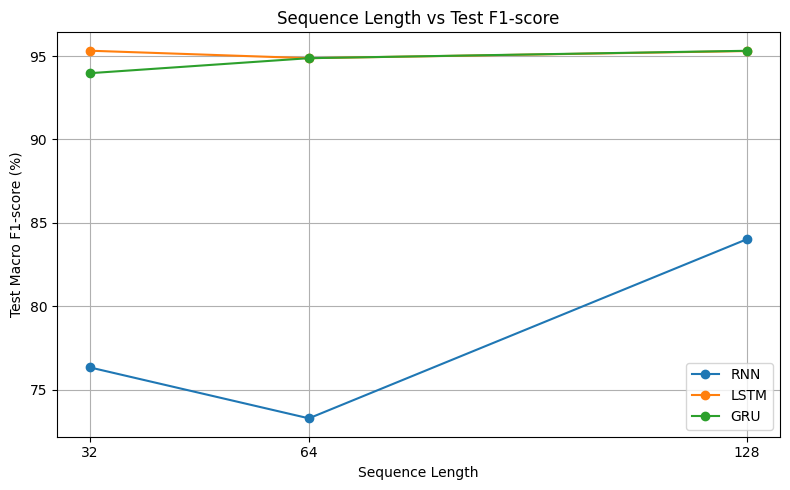

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    sequence_results_df["Sequence Length"],
    sequence_results_df["RNN F1 (%)"],
    marker="o",
    label="RNN"
)

plt.plot(
    sequence_results_df["Sequence Length"],
    sequence_results_df["LSTM F1 (%)"],
    marker="o",
    label="LSTM"
)

plt.plot(
    sequence_results_df["Sequence Length"],
    sequence_results_df["GRU F1 (%)"],
    marker="o",
    label="GRU"
)

plt.xlabel("Sequence Length")
plt.ylabel("Test Macro F1-score (%)")
plt.title("Sequence Length vs Test F1-score")
plt.xticks([32, 64, 128])
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Plot 6 Sequence Length vs Test F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()